# E-Commerce Exploratory Data Analysis

## Table of Contents
1. [Data Loading and Configuration](#1-data-loading-and-configuration)
2. [Data Preparation and Transformation](#2-data-preparation-and-transformation)
3. [Business Metrics Analysis](#3-business-metrics-analysis)
   - 3.1 [Revenue Analysis](#31-revenue-analysis)
   - 3.2 [Product Analysis](#32-product-analysis)
   - 3.3 [Geographic Analysis](#33-geographic-analysis)
   - 3.4 [Customer Experience Analysis](#34-customer-experience-analysis)
4. [Summary of Observations](#4-summary-of-observations)

## Data Dictionary

### Datasets
| Dataset | Description |
|---------|-------------|
| orders_dataset.csv | Order-level data with timestamps and delivery status |
| order_items_dataset.csv | Line items within each order with pricing |
| products_dataset.csv | Product catalog with categories and dimensions |
| customers_dataset.csv | Customer location information (city, state, zip) |
| order_reviews_dataset.csv | Customer reviews with scores and comments |
| order_payments_dataset.csv | Payment information per order |

### Key Columns
| Column | Description |
|--------|-------------|
| order_id | Unique order identifier (prefixed with ord_) |
| order_status | Order lifecycle status: delivered, canceled, pending, processing, shipped, returned |
| order_purchase_timestamp | Datetime when the customer placed the order |
| price | Item sale price in USD |
| product_category_name | Product category (e.g., electronics, books_media) |
| customer_state | US state abbreviation (e.g., CA, TX) |
| review_score | Customer satisfaction rating (1 to 5, where 5 is best) |

### Business Terms
| Term | Definition |
|------|------------|
| Revenue | Sum of item prices for delivered orders |
| AOV | Average Order Value -- mean total price per order |
| MoM Growth | Month-over-month percentage change in a metric |
| YoY Growth | Year-over-year percentage change in a metric |
| Delivery Speed | Number of days from purchase to customer delivery |

## 1. Data Loading and Configuration

Load all e-commerce datasets and define the analysis configuration parameters.
The analysis period and comparison period can be adjusted by changing the configuration variables below.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px

from data_loader import load_and_prepare, filter_delivered, filter_by_date_range, add_delivery_speed
import business_metrics as bm

# ---- Analysis Configuration ----
# Modify these parameters to analyze different time periods
ANALYSIS_YEAR = 2023
COMPARISON_YEAR = 2022
START_MONTH = 1   # January
END_MONTH = 12    # December

DATA_DIR = "ecommerce_data"

# ---- Visualization Settings ----
COLOR_PALETTE = ["#2C5F8A", "#4A90D9", "#7AB8E0", "#A8D5F2", "#3B7DD8",
                 "#1B4F72", "#5DADE2", "#85C1E9", "#2E86C1", "#1A5276",
                 "#6CB4EE", "#3498DB", "#21618C"]
PRIMARY_COLOR = "#2C5F8A"
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 100})

def date_range_label(year, start_month, end_month):
    # Return a human-readable date range string for titles and captions.
    from calendar import month_abbr
    return f"{month_abbr[start_month]} {year} - {month_abbr[end_month]} {year}"

analysis_label = date_range_label(ANALYSIS_YEAR, START_MONTH, END_MONTH)
comparison_label = date_range_label(COMPARISON_YEAR, START_MONTH, END_MONTH)

print(f"Analysis period : {analysis_label}")
print(f"Comparison period: {comparison_label}")

Analysis period : Jan 2023 - Dec 2023
Comparison period: Jan 2022 - Dec 2022


In [3]:
# Load all datasets and build the merged sales DataFrame
datasets, sales_all = load_and_prepare(DATA_DIR)

orders = datasets["orders"]
order_items = datasets["order_items"]
products = datasets["products"]
customers = datasets["customers"]
reviews = datasets["reviews"]

print(f"Orders:      {len(orders):,} rows")
print(f"Order Items: {len(order_items):,} rows")
print(f"Products:    {len(products):,} rows")
print(f"Customers:   {len(customers):,} rows")
print(f"Reviews:     {len(reviews):,} rows")

Orders:      10,000 rows
Order Items: 16,047 rows
Products:    6,000 rows
Customers:   8,000 rows
Reviews:     6,571 rows


In [4]:
# Pricing distribution summary
order_items.describe()[["price", "freight_value"]]

,price,freight_value
count,16047.000000,16047.000000
mean,451.136576,45.509333
std,473.862118,61.182962
min,5.020000,0.000000
25%,94.695000,6.540000
50%,256.360000,19.950000
75%,662.875000,57.770000
max,1999.350000,385.230000


In [5]:
# Product categories available in the catalog
print(f"Unique products: {products['product_id'].nunique():,}")
print(f"Product categories ({products['product_category_name'].nunique()}):")
for cat in sorted(products["product_category_name"].unique()):
    print(f"  - {cat}")

Unique products: 6,000
Product categories (13):
  - automotive
  - baby_products
  - beauty_personal_care
  - books_media
  - clothing_shoes_jewelry
  - electronics
  - grocery_gourmet_food
  - health_personal_care
  - home_garden
  - pet_supplies
  - sports_outdoors
  - tools_home_improvement
  - toys_games


## 2. Data Preparation and Transformation

Filter the merged sales data to delivered orders only, then segment into the
configured analysis and comparison periods.

In [6]:
# Filter to delivered orders only
sales_delivered = filter_delivered(sales_all)

# Split into analysis and comparison periods
sales_current = filter_by_date_range(
    sales_delivered, ANALYSIS_YEAR, START_MONTH, ANALYSIS_YEAR, END_MONTH
)
sales_previous = filter_by_date_range(
    sales_delivered, COMPARISON_YEAR, START_MONTH, COMPARISON_YEAR, END_MONTH
)

# Add delivery speed for customer experience analysis
sales_current = add_delivery_speed(sales_current)

print(f"Total delivered line items: {len(sales_delivered):,}")
print(f"Analysis period ({analysis_label}):   {len(sales_current):,} line items, {sales_current['order_id'].nunique():,} orders")
print(f"Comparison period ({comparison_label}): {len(sales_previous):,} line items, {sales_previous['order_id'].nunique():,} orders")

Total delivered line items: 15,095
Analysis period (Jan 2023 - Dec 2023):   7,448 line items, 4,635 orders
Comparison period (Jan 2022 - Dec 2022): 7,641 line items, 4,749 orders


## 3. Business Metrics Analysis

### 3.1 Revenue Analysis

Key revenue metrics: total revenue, year-over-year growth, monthly trends,
month-over-month growth, average order value, and total order count.

In [7]:
# Total revenue and year-over-year comparison
current_revenue = bm.total_revenue(sales_current)
previous_revenue = bm.total_revenue(sales_previous)
rev_growth = bm.revenue_growth(sales_current, sales_previous)

print(f"Total Revenue ({analysis_label}):   ${current_revenue:,.2f}")
print(f"Total Revenue ({comparison_label}): ${previous_revenue:,.2f}")
print(f"Year-over-Year Revenue Growth: {rev_growth:+.2f}%")

Total Revenue (Jan 2023 - Dec 2023):   $3,360,294.74
Total Revenue (Jan 2022 - Dec 2022): $3,445,076.96
Year-over-Year Revenue Growth: -2.46%


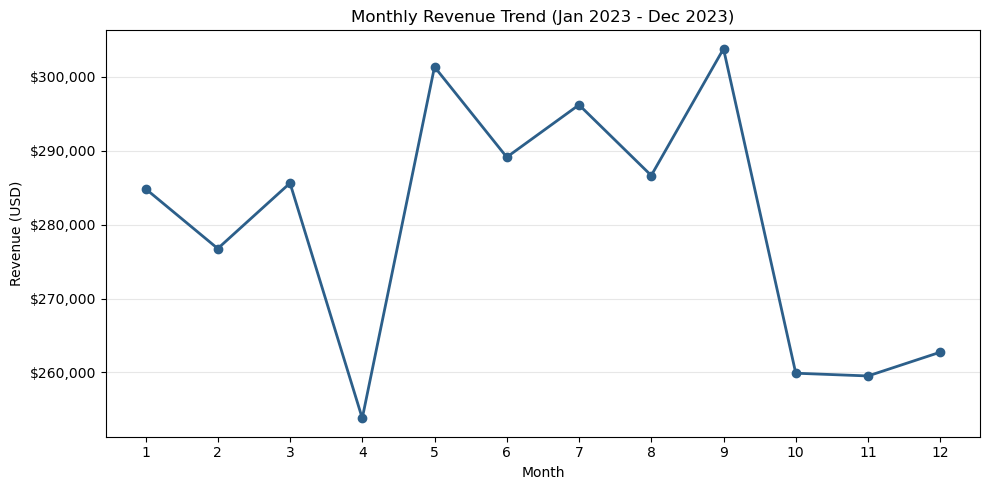

In [8]:
# Monthly revenue trend
monthly_rev = bm.monthly_revenue(sales_current)

fig, ax = plt.subplots()
ax.plot(monthly_rev["month"], monthly_rev["revenue"], marker="o", color=PRIMARY_COLOR, linewidth=2)
ax.set_title(f"Monthly Revenue Trend ({analysis_label})")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Month-over-month revenue growth
mom_growth = bm.monthly_revenue_growth(sales_current)
avg_mom = bm.average_monthly_growth(sales_current)

print("Month-over-Month Revenue Growth:")
for month_num, growth in mom_growth.items():
    if pd.notna(growth):
        print(f"  Month {month_num:2d}: {growth:+.2f}%")
print(f"\nAverage MoM Growth: {avg_mom:+.2f}%")

Month-over-Month Revenue Growth:
  Month  2: -2.84%
  Month  3: +3.20%
  Month  4: -11.14%
  Month  5: +18.74%
  Month  6: -4.06%
  Month  7: +2.45%
  Month  8: -3.23%
  Month  9: +5.98%
  Month 10: -14.45%
  Month 11: -0.14%
  Month 12: +1.24%

Average MoM Growth: -0.39%


In [10]:
# Average order value comparison
current_aov = bm.average_order_value(sales_current)
previous_aov = bm.average_order_value(sales_previous)
aov_change = bm.aov_growth(sales_current, sales_previous)

print(f"Average Order Value ({analysis_label}):   ${current_aov:,.2f}")
print(f"Average Order Value ({comparison_label}): ${previous_aov:,.2f}")
print(f"Year-over-Year AOV Change: {aov_change:+.2f}%")

Average Order Value (Jan 2023 - Dec 2023):   $724.98
Average Order Value (Jan 2022 - Dec 2022): $725.43
Year-over-Year AOV Change: -0.06%


In [11]:
# Total orders comparison
current_orders = bm.total_orders(sales_current)
previous_orders = bm.total_orders(sales_previous)
order_growth = bm.order_count_growth(sales_current, sales_previous)

print(f"Total Orders ({analysis_label}):   {current_orders:,}")
print(f"Total Orders ({comparison_label}): {previous_orders:,}")
print(f"Year-over-Year Order Count Change: {order_growth:+.2f}%")

Total Orders (Jan 2023 - Dec 2023):   4,635
Total Orders (Jan 2022 - Dec 2022): 4,749
Year-over-Year Order Count Change: -2.40%


### 3.2 Product Analysis

Revenue breakdown by product category for the analysis period.

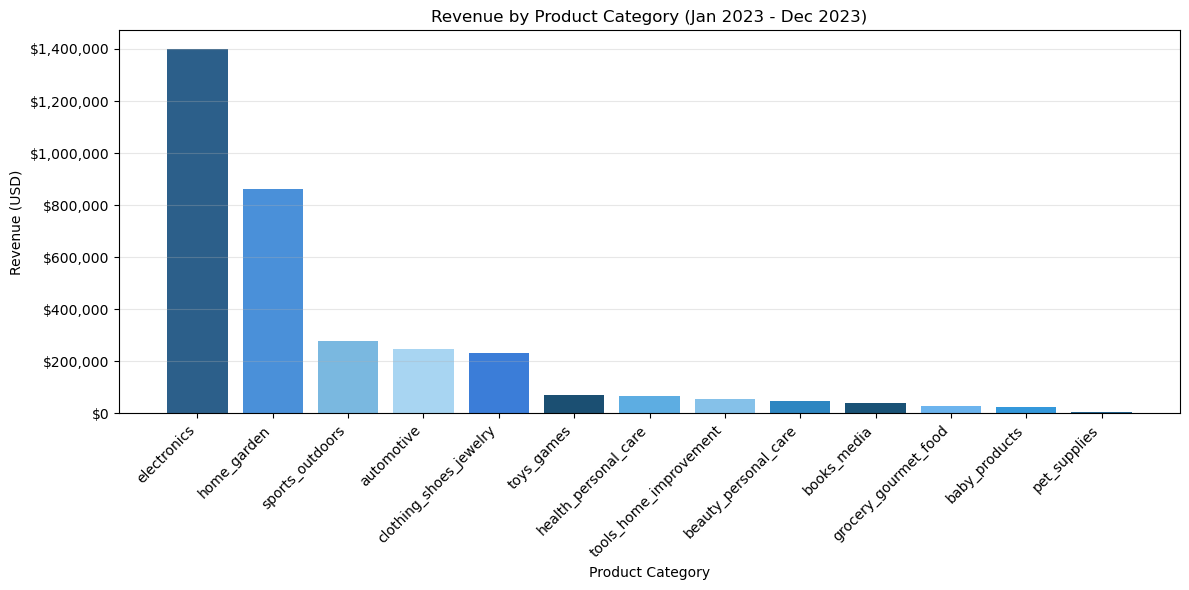

In [12]:
# Revenue by product category
category_rev = bm.revenue_by_category(sales_current, products)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    range(len(category_rev)),
    category_rev["revenue"],
    color=COLOR_PALETTE[:len(category_rev)],
)
ax.set_title(f"Revenue by Product Category ({analysis_label})")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue (USD)")
ax.set_xticks(range(len(category_rev)))
ax.set_xticklabels(category_rev["product_category_name"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Geographic Analysis

Revenue distribution across US states for the analysis period.

In [13]:
# Revenue by state - choropleth map
state_rev = bm.revenue_by_state(sales_current, orders, customers)

fig = px.choropleth(
    state_rev,
    locations="customer_state",
    color="revenue",
    locationmode="USA-states",
    scope="usa",
    title=f"Revenue by State ({analysis_label})",
    color_continuous_scale="Blues",
    labels={"revenue": "Revenue (USD)", "customer_state": "State"},
)
fig.update_layout(geo=dict(bgcolor="rgba(0,0,0,0)"))
fig.show()

### 3.4 Customer Experience Analysis

Customer satisfaction metrics including review scores, delivery speed,
and the relationship between delivery time and customer ratings.

In [14]:
# Average review score by delivery speed (days)
review_by_speed = bm.review_score_by_delivery_speed(sales_current, reviews)
print("Average Review Score by Delivery Speed (days):")
print(review_by_speed.to_string(index=False))

Average Review Score by Delivery Speed (days):
 delivery_speed  review_score
              2      4.033898
              3      4.248555
              4      4.068000
              5      4.054054
              6      4.073529
              7      4.102236
              8      3.965418
              9      4.117470
             10      4.100917
             11      4.146580
             12      4.252066
             13      4.099448
             14      4.175439
             15      4.000000


In [15]:
# Review score by delivery speed category
review_by_category = bm.review_score_by_delivery_category(sales_current, reviews)
print("Average Review Score by Delivery Category:")
print(review_by_category.to_string(index=False))

Average Review Score by Delivery Category:
delivery_category  review_score
         1-3 days      4.193966
         4-7 days      4.075063
          8+ days      4.108138


In [16]:
# Overall average review score
avg_score = bm.average_review_score(sales_current, reviews)
print(f"Average Review Score ({analysis_label}): {avg_score:.2f} / 5")

Average Review Score (Jan 2023 - Dec 2023): 4.10 / 5


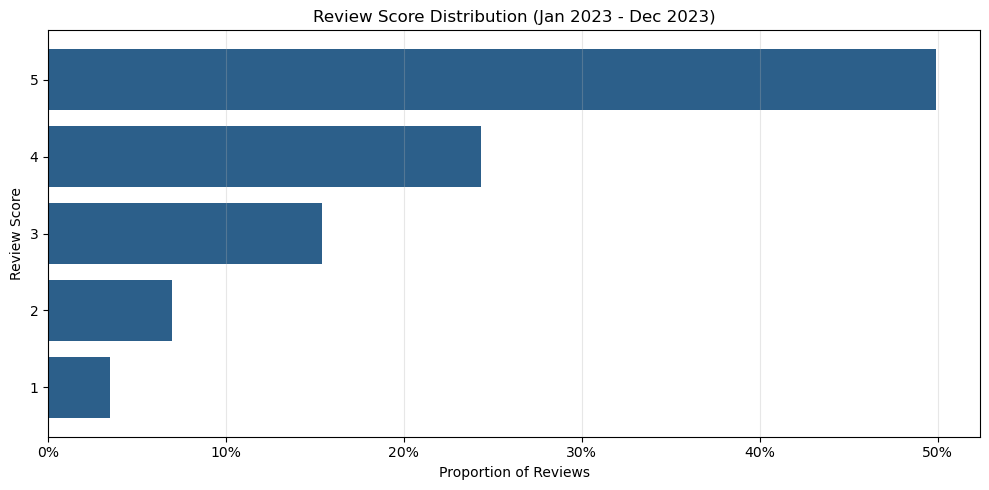

In [17]:
# Review score distribution
score_dist = bm.review_score_distribution(sales_current, reviews)

fig, ax = plt.subplots()
ax.barh(
    score_dist.index.astype(str),
    score_dist.values,
    color=PRIMARY_COLOR,
)
ax.set_title(f"Review Score Distribution ({analysis_label})")
ax.set_xlabel("Proportion of Reviews")
ax.set_ylabel("Review Score")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Order status distribution
status_dist = bm.order_status_distribution(orders, ANALYSIS_YEAR)
print(f"Order Status Distribution ({ANALYSIS_YEAR}):")
for status, proportion in status_dist.items():
    print(f"  {status:12s}: {proportion:.2%}")

Order Status Distribution (2023):
  delivered   : 93.64%
  shipped     : 3.19%
  canceled    : 1.29%
  processing  : 1.19%
  pending     : 0.51%
  returned    : 0.18%


In [19]:
# Delivery speed statistics
speed_stats = bm.delivery_speed_stats(sales_current)
print(f"Delivery Speed Statistics ({analysis_label}):")
print(f"  Mean:   {speed_stats['mean']:.1f} days")
print(f"  Median: {speed_stats['median']:.1f} days")
print(f"  Min:    {speed_stats['min']} days")
print(f"  Max:    {speed_stats['max']} days")

Delivery Speed Statistics (Jan 2023 - Dec 2023):
  Mean:   8.0 days
  Median: 8.0 days
  Min:    2 days
  Max:    15 days


## 4. Summary of Observations

### Revenue
- Total revenue and year-over-year growth rate are reported above.
- Monthly revenue trend shows the seasonal pattern across the analysis period.
- Average month-over-month growth indicates the overall direction of revenue within the period.

### Orders
- Total order count and year-over-year change provide a volume perspective.
- Average order value (AOV) and its year-over-year change show whether customers are spending more or less per order.

### Product Performance
- Revenue by product category identifies the highest and lowest revenue-generating categories.
- The category ranking can inform inventory and marketing prioritization.

### Geographic Distribution
- The state-level revenue map reveals geographic concentration of sales.
- States with the highest revenue may warrant focused marketing or logistics investment.

### Customer Experience
- The relationship between delivery speed and review scores shows how fulfillment affects satisfaction.
- The overall average review score and its distribution provide a baseline for customer experience measurement.
- Order status proportions indicate operational fulfillment rates.

---
*Analysis generated from the configurable e-commerce EDA framework. Adjust ANALYSIS_YEAR, COMPARISON_YEAR, START_MONTH, and END_MONTH in the configuration cell to analyze different periods.*